=== Scenario 3: Random Forest ===
Trees: 10 | Accuracy: 1.0000
Trees: 50 | Accuracy: 1.0000
Trees: 100 | Accuracy: 1.0000
Trees: 150 | Accuracy: 1.0000
Trees: 200 | Accuracy: 1.0000
\nBest Accuracy: 1.0000 with 10 trees


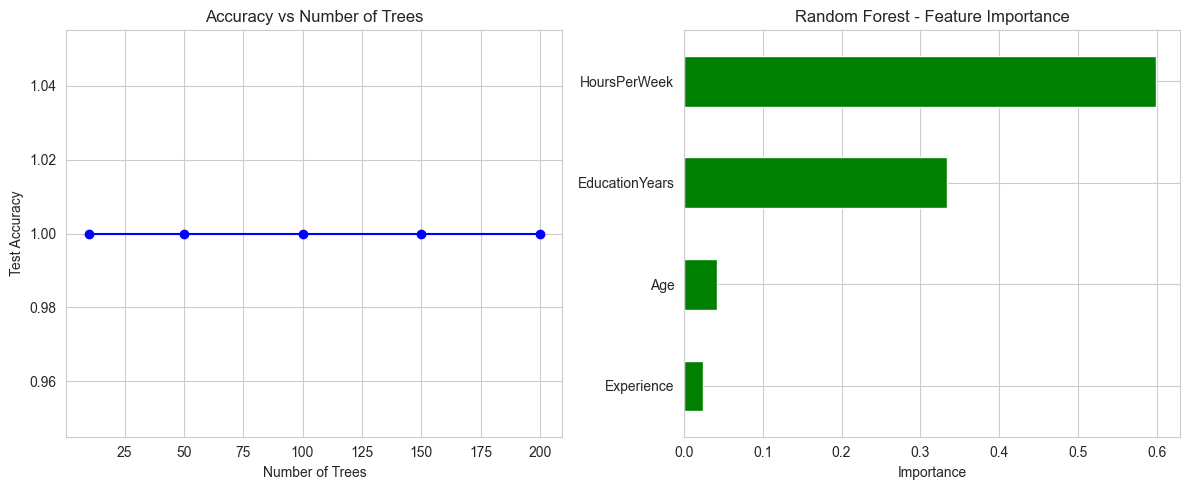

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

def main():
    # Load Data
    df = pd.read_csv('../dataset/income_random_forest.csv')

    X = df.drop('Income', axis=1)
    y = df['Income']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    # Train and Tune Random Forest
    n_estimators_list = [10, 50, 100, 150, 200]
    accuracies = []

    best_rf = None
    best_acc = 0

    print("=== Scenario 3: Random Forest ===")
    for n in n_estimators_list:
        rf = RandomForestClassifier(n_estimators=n, random_state=42)
        rf.fit(X_train, y_train)
        pred = rf.predict(X_test)
        acc = accuracy_score(y_test, pred)
        accuracies.append(acc)
        print(f"Trees: {n} | Accuracy: {acc:.4f}")

        if acc > best_acc:
            best_acc = acc
            best_rf = rf

    print(f"\\nBest Accuracy: {best_acc:.4f} with {best_rf.n_estimators} trees")

    # Visualization
    plt.figure(figsize=(12, 5))

    # Accuracy vs Number of Trees
    plt.subplot(1, 2, 1)
    plt.plot(n_estimators_list, accuracies, marker='o', linestyle='-', color='b')
    plt.title('Accuracy vs Number of Trees')
    plt.xlabel('Number of Trees')
    plt.ylabel('Test Accuracy')
    plt.grid(True)

    # Feature Importance
    plt.subplot(1, 2, 2)
    feat_importances = pd.Series(best_rf.feature_importances_, index=X.columns)
    feat_importances.sort_values().plot(kind='barh', color='g')
    plt.title('Random Forest - Feature Importance')
    plt.xlabel('Importance')

    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    main()
